# Tanzania Tourism Prediction

Authors:

1. Jedidiah Wambui
2. Pauline Onyango
3. Dave Karanja

Project Repository:
GitHub: https://github.com/karanja-dave/NgaoLabs/tree/main/Tanzania_tourism_prediction

NB: Ensure all dataset files are stored in a data folder in unzipped format. This prevents file path errors and ensures smooth, consistent data loading during analysis.

Date:
22 February 2026

## Project Objective
This notebook presents the exploratory data analysis (EDA) and preprocessing conducted on tourism data in Tanzania prior to predictive modeling. The purpose of this analysis is to:

- Understand the structure, distributions, and patterns of tourist-related data
- Detect missing values, anomalies, and inconsistencies across features
- Assess categorical variable distributions and high-cardinality features
- Examine relationships between features and the target variable (`total_cost`)
- Guide feature engineering, encoding, and model preparation decisions

**General Objective**
Analyze and preprocess tourism data in Tanzania to model tourist expenditure patterns and identify key factors affecting spending.

**Specific Objectives**

1. **Data Cleaning**: Handle missing values in both categorical and numerical columns, correct inconsistencies (`age_group`), and prepare features for analysis.
2. **EDA**: Explore distributions, detect outliers, visualize correlations, and examine categorical imbalances.
3. **Feature Engineering**: Created features such as total_people, total_nights, package_count, and ratios for mainland and Zanzibar, while dropping redundant or highly correlated features to avoid multicollinearity.
4. **Encoding**: Apply label encoding to ordered categorical variables (`age_group`) and OHE to unordered categorical variables. Encoded high-cardinality features (`country`) using cross-validated target encoding.
5.  Ensure train and test sets have consistent features for modeling by using function for wrangling and encoding
6. **Data Partitioning**: Split the processed data into training and validation sets for model evaluation.

This framework ensures consistency, completeness, and reproducibility in analyzing tourist expenditure patterns across Tanzania.

In [2]:
### import libraries for: 
#EDA
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#preprocessing 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

## Data Preparation

The tourism dataset was loaded and inspected for missing values, guided by insights from EDA. Categorical fields (`travel_with`, `most_impressing`) were imputed with the most frequent values, and numerical fields (`total_female`, `total_male`) were filled using the median based on observed skewness. Feature engineering created new variables including `total_people`, `total_nights`, `package_count`, and the proportion of nights spent on the mainland. Columns used for feature creation and one highly correlated ratio were dropped to avoid multicollinearity. This wrangling process, guided by EDA, produced a clean and consistent dataset ready for visualization and modeling.

In [3]:
# wrangle function
def wrangle(path):
    # load data 
    df=pd.read_csv(path)
    ## imputation of missing values 
    #categorical variables 
    cate_cols = ['travel_with', 'most_impressing'] #select cols with missing values 
    modes = df[cate_cols].mode().iloc[0] #get mode of these cols
    df[cate_cols] = df[cate_cols].fillna(modes) #impute missing values in these cols
    #numerical variables 
    cols = ['total_female', 'total_male']
    df[cols] = df[cols].fillna(df[cols].median())
    # drop high cardinality fetures 
    # df.drop(columns='country',inplace=True)

    ## feature engineering 
    #total people
    df["total_people"] = df["total_male"] + df["total_female"]
    #total nights
    df["total_nights"] = df["night_mainland"] + df["night_zanzibar"]

    # count total packages 
    pkg_cols = df.filter(like='package_').columns #select cols with package name 
    df['package_count'] = (df[pkg_cols] == 'Yes').sum(axis=1)

    # ratios
    df['mainland_ratio'] = df['night_mainland'] / (df['total_nights'] + 1e-6)
    df['zanzibar_ratio'] = df['night_zanzibar'] / (df['total_nights'] + 1e-6)
    
    #drop cols used in feat engineering to avid multicolllinearity
    df.drop(columns=list(pkg_cols)+['total_male', 'total_female', 'night_mainland', 'night_zanzibar'],inplace=True)
    #drop one ratio to avoid multicollinearity as they have very high correlation
    df.drop(columns='zanzibar_ratio',inplace=True)

    return df 

In the wrangle function, the new features were created based on insights from the EDA. `total_people` and `total_nights` were calculated by summing the number of males and females, and the nights spent in mainland Tanzania and Zanzibar, respectively. This aggregation reduces dimensionality and redundancy. The information from the original columns is preserved in the totals, so no predictive signal is lost.

`package_count` was derived by summing all purchased services in a tourist’s package to provide a single numeric indicator of how comprehensive a tourist’s package is, capturing overall package complexity without overloading the model with sparse binary indicators. 

Additionally, `mainland_ratio` and `zanzibar_ratio` were computed to express the proportion of nights spent in each location relative to the total, offering context beyond raw counts. To prevent multicollinearity, one ratio was dropped, which does not bias the model because the remaining ratio fully represents the relative distribution of nights (`zanzibar_ratio`=1-`mainland_ration` and viceversa). These engineered features enhance interpretability and reduce redundancy, ensuring the model can effectively learn patterns without losing information.

In [6]:
# load data using wrangle func 
train=wrangle('../data/Train.csv')
test=wrangle('../data/Test.csv')

The datasets were loaded using the wrangling function to ensure consistent formatting, feature creation in the train and test sets and that the data was prepared for effective use in analysis and model building

In [ ]:
# dealing with incosistencies in the `age_group` col 
train['age_group'].unique()
test['age_group'].unique()
test['age_group'] = test['age_group'].replace({'24-Jan': '1-24'})

During preprocessing, an inconsistency was detected in the `age_group` column of the test dataset, where a value `24-Jan` appeared instead of the expected `1-24` format. This mismatch caused the feature preprocessing function to fail, as label encoding requires consistent categories between train and test sets. The issue was resolved by replacing `24-Jan` with `1-24`, ensuring alignment of categorical values and allowing the preprocessing pipeline to execute without errors.

You will interact with the preprocessing function below after dealing with visualization.

## Explanatory Data Analysis (EDA)
EDA was performed to understand the structure, distribution, and quality of the datasets. This included examining numerical and categorical variables, detecting missing values, identifying outliers, and visualizing patterns. The insights gained from EDA guided feature engineering, data cleaning decisions, and informed the preparation of the datasets for modeling.

In [ ]:
###EDA
##check data structure and format
train.head() #obv first 5 rows
train.info()

## check for missing values 
train.isna().mean()>0.5 
print('\n No variable has atleast 50% proportion of missing values.\n Imputation to be carried out on missing values\n')
train.isna().sum()



# examine cols with missing values individually 
#categorical examintaion
print('\nBefore imputation for categorical variables we need to know the mode which will be used for imputation\n')
train['travel_with'].unique() #check unique values in categorical variable
train['travel_with'].mode()[0] ##what is the most occurring unique value?

train['most_impressing'].unique()
train['most_impressing'].mode()[0]

#numerical examination
print("\nBefore imputation, we check for skewness in individual numerical variables.\nThis helps us know whetehr to use mean or median for imputation\n")
train['total_female'].skew()
train['total_male'].skew()
print('\nBoth numerical columns are right skewed. Imputation should be done using median\n')


# outliers 


## dealing with cardinality
train.select_dtypes(include='object').nunique()
train['country'].unique()

# categorical analysis based on cardinality 
cate_var = train.select_dtypes(include="object")
for col in cate_var:
    print(f"{col}: {train[col].nunique()} unique values")
    print(train[col].value_counts(dropna=False))
    print("-"*50)






In the EDA phase, the dataset was examined to understand its structure, quality, and characteristics before modeling. Initial checks involved inspecting the first few rows and using `.info()` to verify column types and completeness. Missing values were assessed column wise, confirming that no variable exceeded the 50% missing values proportion, with imputation planned for identified gaps. Categorical variables with missing values, such as `travel_with` and `most_impressing`, were explored to determine their modes for imputation. Numerical variables `total_female` and `total_male` were evaluated for skewness, revealing right-skewed distributions and justifying median imputation.

The analysis also addressed high-cardinality columns, specifically `country`, which was recognized as potentially informative and thus retained for transformation using cross-validated target encoding rather than being dropped. A detailed examination of all categorical variables included counts of unique values and frequency distributions, which highlighted distinctions between ordered and unordered categories, guiding the application of both label encoding and one-hot encoding to appropriate features. This EDA process ensured a clear understanding of variable distributions, missingness, and encoding requirements, forming a robust foundation for preprocessing and model development.

## Visualization
The visualization carried to visualize patterns, relationships, and distributions within the tourism dataset. Visual plots such as heatmaps, histograms, bar charts, boxplots, and scatter plots allow clearer identification of correlations, outliers, skewness, categorical imbalances, and potential linear relationships with the target variable (`total_cost`). These visualizations support model selection decisions, validate preprocessing choices, and ensure that underlying assumptions—particularly for linear modeling—are reasonably satisfied before training predictive models.

### Heatmap
The heatmap displays correlations among numerical features, helping identify the strength and direction of linear relationships. Its main purpose is to detect multicollinearity, which can cause redundancy and instability in linear models, thereby guiding feature reduction decisions.

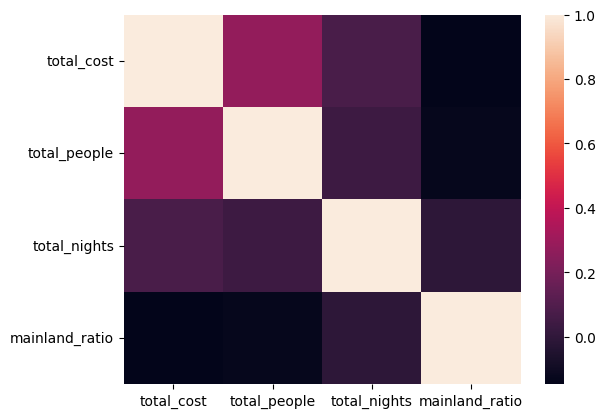

In [8]:
#dealing with multicollinearity
corr= train.select_dtypes("float64").corr()
sns.heatmap(corr)
plt.show()

The heatmap shows generally weak linear relationships among the numerical features. `total_people` has a modest positive correlation with `total_cost` , while `total_nights` shows a very weak positive relationship. `mainland_ratio` has a weak negative correlation with `total_cost` . Importantly, no strong correlations are observed among the features, indicating low multicollinearity. However, `zanzibar_ratio` was dropped prior to modeling because it was highly correlated with `mainland_ratio` , and retaining both would introduce redundancy and multicollinearity without adding new information.

### Histogram
A histogram visualizes the distribution of numerical variables by showing the frequency of values across intervals. Its significance lies in identifying skewness, spread, and potential outliers, which informs imputation choices, transformation needs, and overall modeling strategy.

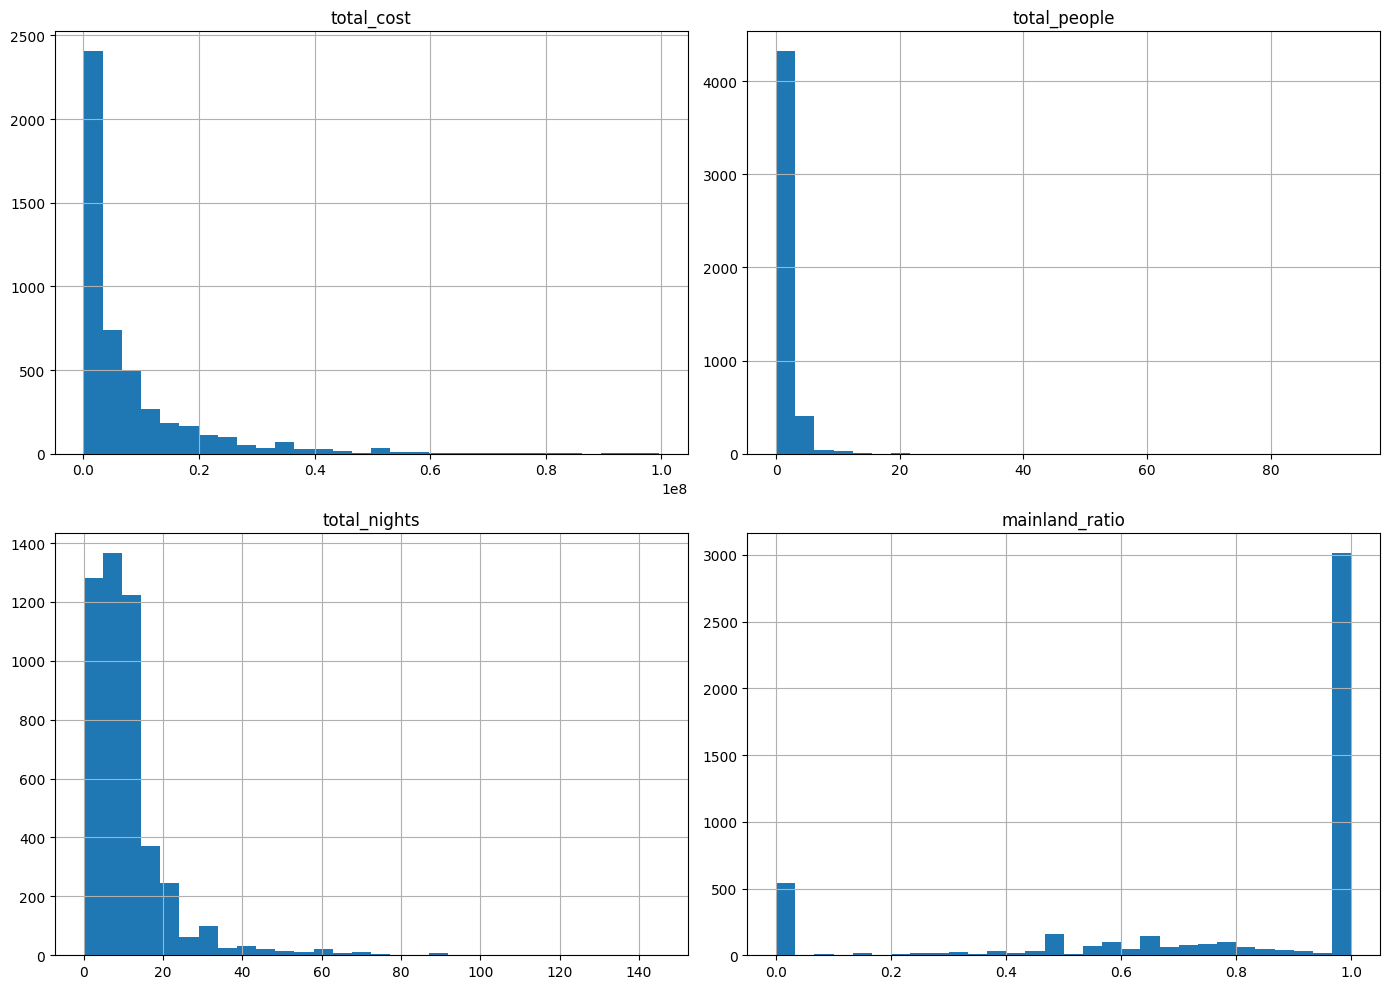

In [7]:
#distribution of numerical cols 
num_cols = train.select_dtypes(include="float64")
train[num_cols.columns].hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()

The histograms indicate that most numerical variables are positively skewed, with `total_cost` heavily right skewed as most tourists spend relatively low amounts while a few exhibit extremely high expenditures, `total_people` is also right-skewed with most tourists traveling alone or in small groups, and `total_nights` showing short stays for the majority but a few extended stays. The `mainland_ratio` is concentrated near 1, reflecting that most tourists spend most nights on mainland Tanzania rather than Zanzibar. These distributions demonstrate non-normality and the presence of extreme values, which can distort the assumptions of linear regression, particularly homoscedasticity and normality of residuals, thereby justifying the use of log transformations to stabilize variance and reduce the influence of outliers if a linear model was to be used.

### Barchart
A bar chart visualizes the distribution of categorical variables by showing the frequency of each category using bars. Its significance lies in identifying dominant or rare categories, comparing groups, and guiding encoding decisions, feature selection, and interpretation in modeling.

In [ ]:
def plot_barh(df, col, ax):
    df[col].value_counts().plot(
        kind='bar',
        ax=ax,
        color='skyblue'
    )
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel("Count")
    ax.set_ylabel(col)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))  # 3 rows × 3 columns
axes = axes.flatten()

plot_barh(train, 'age_group', axes[0])
plot_barh(train, 'travel_with', axes[1])
plot_barh(train, 'purpose', axes[2])
plot_barh(train, 'main_activity', axes[3])
plot_barh(train, 'info_source', axes[4])
plot_barh(train, 'tour_arrangement', axes[5])
plot_barh(train, 'payment_mode', axes[6])
plot_barh(train, 'first_trip_tz', axes[7])
plot_barh(train, 'most_impressing', axes[8])

plt.tight_layout()
plt.show()


make barchart plots presentable 

### Boxplots 
A boxplot shows a dataset’s distribution through its quartiles, highlighting the median, interquartile range, and outliers. It is significant because it summarizes central tendency, variability, skewness, and extreme values, helping quickly identify unusual observations.

In [ ]:
# select numerical columns
num_cols = train.select_dtypes(include='float64').columns

# create subplots grid
n_cols = 3  # number of columns in the grid
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # calculate required rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()  # flatten for easy indexing

# plot boxplots for each numerical column
for i, col in enumerate(num_cols):
    train.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The boxplots of total_cost, total_people, total_nights, and mainland_ratio reveal substantial skewness and extreme values: most tourists spend relatively low amounts, travel in small groups, and stay for short periods, while a few exhibit extremely high expenditures, large group sizes, or extended stays. Values of mainland_ratio cluster near 1, indicating most nights are spent on the mainland, with only a few lower outliers. These outliers are retained because they reflect genuine tourist behavior rather than errors; removing them would eliminate critical information about high-spending tourists or unusual travel patterns. Instead, transformations such as logarithms or robust modeling approaches are applied to mitigate their influence while preserving the full range of meaningful data.

### Scatter Plots
A scatter plot displays the relationship between two numerical variables, with each point representing a paired observation. It is significant because it reveals trends, correlations, and outliers, guiding analysis and modeling decisions.

In [ ]:
#scatter plot 
# List of numerical features to plot against total_cost
num_vars = ['total_people', 'total_nights', 'mainland_ratio']

# Create a grid of scatter plots
fig, axes = plt.subplots(1, len(num_vars), figsize=(18, 5))

for i, var in enumerate(num_vars):
    sns.scatterplot(data=train, x=var, y='total_cost', ax=axes[i])
    axes[i].set_title(f'{var} vs Total Cost')

plt.tight_layout()
plt.show()

The scatter plots indicate that total_cost is highly right-skewed, with a few extremely large values and most observations concentrated at lower levels. Additionally, the spread of total_cost increases as total_people and total_nights increase, suggesting heteroskedasticity (non-constant variance). The relationships also appear non-linear rather than strictly linear. These characteristics violate key assumptions of ordinary least squares regression, particularly constant variance and normally distributed errors. Therefore, applying a logarithmic transformation to total_cost is necessary to reduce skewness, stabilize the variance, and linearize the relationships, making the data more suitable for fitting a linear regression model.

## Encoding 
Encoding converts categorical data into numerical form so machine learning models can process it, since most algorithms cannot handle text labels directly. In this dataset, three types of encoding are applied: label encoding for `age_group`, which assigns an integer to each ordered category; one-hot encoding (OHE) for nominal variables without any order, and cross-validated target encoding for `country`, which has high cardinality, replacing each category with a statistic (e.g., mean target grouped by country) computed using cross-validation to prevent leakage and overfitting.

**1. Cross Validation Target Encoding**

Cross-validated target encoding replaces each category with the grouped mean (groupinng is done based on each unique value of the categorical variable) of the target variable, computed using only training folds to prevent leakage. Rare or unseen categories are replaced with the global training mean for stability. This method is supported by Micci-Barreca (2001), Kuhn & Johnson (2013), and Vanschoren et al. (2019) as a standard approach for encoding high-cardinality categorical features.

In [ ]:
##encoding the country column
#train
train['country_encoded'] = np.nan
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(train):
    train_fold = train.iloc[train_idx]
    val_fold = train.iloc[val_idx]
    
    country_mean = train_fold.groupby('country')['total_cost'].mean()
    
    train.loc[val_idx, 'country_encoded'] = val_fold['country'].map(country_mean)

# fill missing/unseen categories with global mean
train['country_encoded']=train['country_encoded'].fillna(train['total_cost'].mean())
# drop `country` col
train.drop(columns='country',inplace=True)

#test encoding of country column
test['country_encoded'] = test['country'].map(country_mean)
#fill missing values 
test['country_encoded']=test['country_encoded'].fillna(train['total_cost'].mean())
# drop `country`col 
test.drop(columns='country',inplace=True)

The code performs cross-validated target encoding for the `country` column. For the training set, it splits the data into 5 folds using KFold. For each fold, it calculates the mean `total_cost` per country from the training portion of the fold and maps these means onto the validation portion. Any categories in the validation fold that do not exist in the training fold produce NaNs, so these are replaced with the global mean of total_cost from the full training set. This approach (imputing NaNs with global mean of `total_cost`), is supported by Micci-Barreca (2001), Kuhn & Johnson (2013), and Vanschoren et al. (2019), ensures stable, leakage-free encoding by substituting the marginal target expectation for undefined conditional means. The original country column is then dropped. For the test set, the same mapping is applied using the means computed from the full training set, and unseen categories are again filled with the global training mean before dropping the column.

We use the training set’s grouped means on the test set to avoid data leakage. The test set is unseen data, so we can’t use its target values to compute encodings. Using only the training means ensures the model learns from training data only, and any new categories in the test set are filled with the training set’s overall mean to keep the encoding valid.

**2. Lable and One Hot Encoding**

The dataset separates features and target before encoding. Label encoding is applied to the ordinal age_group, converting categories to integers, while one-hot encoding is applied to nominal categorical columns, creating binary columns for each category. This ensures all categorical features are numerically represented for modeling.

In [ ]:
# define categorical and label cols
categ_cols = train.select_dtypes(include='string').columns.drop(['age_group', 'ID'])
label_cols = ["age_group"]

#init transformers
ohe = OneHotEncoder(drop='first', sparse_output=False)
le_feature = {col: LabelEncoder() for col in label_cols}

def feature_preprocessing(data, fit=True):
    data = data.drop(columns=['ID'], errors='ignore')
    
    #label encoding
    for col in label_cols:
        if fit:
            le_feature[col].fit(data[col].astype(str))
        data[col] = le_feature[col].transform(data[col].astype(str))
    
    # OHE
    if fit:
        ohe_array = ohe.fit_transform(data[categ_cols])
    else:
        ohe_array = ohe.transform(data[categ_cols])
    
    ohe_df = pd.DataFrame(
        ohe_array,
        columns=ohe.get_feature_names_out(categ_cols),
        index=data.index
    )
    
    # Drop original categorical columns and concatenate OHE
    data = data.drop(columns=categ_cols)
    data = pd.concat([data, ohe_df], axis=1)
    
    return data

#split target
X_train=train.drop(['total_cost'],axis=1)
y_train=train['total_cost']

#encoding trnasformation
encoded_train=feature_preprocessing(X_train, fit=True)
encoded_test=feature_preprocessing(test, fit=False)

The function converts categorical features into numerical form for modeling by applying label encoding to the ordinal age_group and one-hot encoding to all other nominal categorical columns. The feature_preprocessing function drops the ID column, encodes the categorical features, drops the originals, and concatenates the encoded columns. The fit argument determines whether the encoders learn from the data (fit=True for training) or just apply existing mappings (fit=False for test), ensuring consistent encoding without data leakage. `encoded_train` fits and transforms the training data, while `encoded_test` transforms the test data using the encoders learned from training.

### Train-Validation Split for Model Evaluation
The final step splits the training data into a training set and a validation set. This allows the model to be trained on one portion while its performance is evaluated on unseen data, ensuring a more reliable assessment before testing on the final test set.

In [ ]:
# split train and validation sets 
X_Train1, X_val, y_Train, y_val = train_test_split(
    encoded_train, y_train, test_size=0.1, random_state=42
)

The data is split with a 10% threshold for validation (test_size=0.1), meaning 90% of the training set is used for model training and 10% for validation.

The complete workflow begins with data loading and cleaning, imputing missing categorical values with the mode and numerical values with the median, performing feature engineering to create totals, counts, and ratios, and dropping redundant or highly correlated columns. Exploratory data analysis includes inspecting distributions with histograms and bar charts to understand numerical skewness, categorical frequencies, and multicollinearity. For preprocessing, cross-validated target encoding is applied to the high-cardinality country column, while other categorical features are converted using label encoding for age_group and one-hot encoding for nominal features. Features and target are separated, and the training data is split into training and validation sets to enable reliable model evaluation. This fully prepares the dataset for the next step: fitting machine learning models.